In [43]:
# Cifar10 data loading and preprocessing
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Transformations for data augmentation and normalization
# Light augmentation helps GANs learn more robustly on CIFAR-10.
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Transformations for validation set
transformVal = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    # No random transformations for validation set
    # This ensures that the validation set is used as a representative sample of the data
])

# Download and load the CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= True,
    download=True,
    transform=transform
)

# Download and load the CIFAR-10 dataset
val_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train= False,
    download=True,
    transform=transformVal
)

# Define batch size which can be adjusted based on how well the model trains and the available computational resources
batch_size = 128

# Create DataLoaders for training and validation datasets
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffling the training data to ensure that the model does not learn the order of the data and generalizes better
    num_workers=2  # Number of subprocesses to use for data loading. 0 means that the data will be loaded in the main process, which can be slower. Setting it to 2 allows for faster data loading by using two subprocesses.
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data as it is only used for evaluation
    num_workers=2 
)

print(f"Dataset: CIFAR-10")
print(f"Number of classes: 10")
print(f"Image size: 32x32 pixels")
print(f"Batch size: {batch_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Dataset: CIFAR-10
Number of classes: 10
Image size: 32x32 pixels
Batch size: 128
Training samples: 50000
Validation samples: 10000
Using device: cuda


In [44]:
# Creating VAE Model
import torch 
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()

        #Encoder 
        # Takes in a 3x32x32 image and compresses it to a latent representation of size latent_dim
        # Uses LeakyReLU to avoid dead neurons and improve gradient flow
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # Output: 512x1x1
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(), # Output: 512*1*1 = 512
        )

        # Mapping the flattened vector to the mean and log variance of the latent distribution
        self.fc_mu = nn.Linear(512, latent_dim) # Mean of the latent distribution
        self.fc_logvar = nn.Linear(512, latent_dim) # Log variance of the latent distribution

        # linear layer to expand latent vector before decoding
        self.decoder_input = nn.Linear(latent_dim, 512)

        #Decoder
        # Maps the latent vector back to the original image space
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), # Output: 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # Output: 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # Output: 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # Output: 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # Output: 3x32x32
            nn.Tanh(), # Output pixel values between -1 and 1; no BatchNorm here as it distorts outputs before Tanh
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x) # Get the mean of the latent distribution
        logvar = self.fc_logvar(x) # Get the log variance of the latent distribution
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        # using log variance to calculate the standard deviation
        std = torch.exp(0.5*logvar) # Standard deviation of the latent distribution
        eps = torch.randn_like(std) # Random noise sampled from a standard normal distribution
        return mu + eps*std # Reparameterization trick to sample from the latent distribution
    
    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 512, 1, 1) # Reshape to 512x1x1 to match the first ConvTranspose2d input
        x = self.decoder(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x) # Encode the input image to get the mean and log variance of the latent distribution
        z = self.reparameterize(mu, logvar) # Sample from the latent distribution using the reparameterization trick
        reconstructed_x = self.decode(z) # Decode the sampled latent vector to get the reconstructed image
        return reconstructed_x, mu, logvar
    
# Instantiate the VAE model and move it to the appropriate device (GPU if available, otherwise CPU)
vae = VAE(latent_dim=128).to(device)
print(vae)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001CA6E630180>
Traceback (most recent call last):
  File "C:\Users\Alex\ml_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "C:\Users\Alex\ml_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1665, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001CA6E630180>
Traceback (most recent call last):
  File "C:\Users\Alex\ml_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "C:\Users\Alex\ml_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1665, in _shutdown_workers
    if self._persistent_workers or self._

VAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_run

In [45]:
# Calculating the ELBO loss for the VAE
import torch.optim as optim
import torch.nn.functional as F

def elbo_loss(recon_x, x, mu, logvar, beta=0.1):
    # Calculate MSE per pixel, then sum across pixels, then mean across the batch
    recon_loss = F.mse_loss(recon_x, x, reduction='none')
    recon_loss = recon_loss.view(recon_x.size(0), -1).sum(dim=1).mean()

    # Sum KL divergence across latent dimensions, then mean across the batch
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# model instance should already be created and moved earlier; ensure it's on correct device
vae = vae.to(device)

#Standard optimizer adam
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

epochs  = 80

# Cosine annealing scheduler: smoothly decays the learning rate from 1e-3 toward 0
# over the course of training, allowing finer weight updates in later epochs.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

# KL annealing: beta linearly ramps from 0 to beta_max over the warmup period,
# letting the model learn good reconstructions before the KL term kicks in.
# A lower beta_max (0.5) reduces blurriness by not over-regularizing the latent space.
kl_warmup_epochs = 10
beta_max = 0.5

# Lists to store the average losses for each epoch
history_total_loss = []
history_recon_loss = []
history_kl_loss = []
history_val_loss = []
history_beta = []

import time
start_time = time.time()

print("Starting training...")

# Initialize best validation loss to infinity
best_val_loss = float('inf')

vae.train()
for epoch in range(epochs):
    # KL annealing: linearly increase beta from 0 to beta_max over the warmup period
    beta = min(beta_max, beta_max * (epoch / kl_warmup_epochs))
    history_beta.append(beta)

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device) # Move the input data to the same device as the model

        # Zero the gradients before backpropagation
        optimizer.zero_grad()

        # Complete the forward pass through the VAE model
        recon_batch, mu, logvar = vae(data)

        # Calculate the ELBO loss with current annealed beta
        loss, recon_loss, kl_loss = elbo_loss(recon_batch, data, mu, logvar, beta=beta)

        # Backpropagation and optimization step
        loss.backward()
        optimizer.step()

        # Accumulate losses; elbo_loss already returns batch-mean values
        train_loss += loss.item()
        train_recon += recon_loss.item()
        train_kl += kl_loss.item()

    # Average over the number of batches in this epoch
    num_batches = len(train_loader)
    avg_loss = train_loss / num_batches
    avg_recon = train_recon / num_batches
    avg_kl = train_kl / num_batches

    # Store the values for plotting later
    history_total_loss.append(avg_loss)
    history_recon_loss.append(avg_recon)
    history_kl_loss.append(avg_kl)

    vae.eval() # Set the model to evaluation mode for validation
    val_loss = 0.0

    #Disable gradient calculation for validation to save memory and computation
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)
            recon_batch, mu, logvar = vae(data)
            loss, _, _ = elbo_loss(recon_batch, data, mu, logvar, beta=beta)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    history_val_loss.append(avg_val_loss)

    # Step the LR scheduler after each epoch
    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}] - Beta: {beta:.3f}, LR: {scheduler.get_last_lr()[0]:.6f}, Total Loss: {avg_loss:.4f}, Recon Loss: {avg_recon:.4f}, KL Loss: {avg_kl:.4f}, Val Loss: {avg_val_loss:.4f}")

    # save best model each epoch
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(vae.state_dict(), 'best_vae.pth') # Save the best model

vae.load_state_dict(torch.load('best_vae.pth')) # Load the best model after training is complete
end_time = time.time()
vae_train_time = end_time - start_time
print(f"Training complete. Best model loaded.")
print(f"Total training time: {vae_train_time:.2f} seconds")

total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda
Starting training...
Epoch [1/80] - Beta: 0.000, LR: 0.001000, Total Loss: 462.6742, Recon Loss: 462.6742, KL Loss: 90554111.5003, Val Loss: 338.6074
Epoch [2/80] - Beta: 0.050, LR: 0.000998, Total Loss: 307.3409, Recon Loss: 300.2621, KL Loss: 141.5762, Val Loss: 269.9478
Epoch [3/80] - Beta: 0.100, LR: 0.000997, Total Loss: 254.9430, Recon Loss: 244.4623, KL Loss: 104.8073, Val Loss: 244.2568
Epoch [4/80] - Beta: 0.150, LR: 0.000994, Total Loss: 236.6807, Recon Loss: 224.5168, KL Loss: 81.0927, Val Loss: 224.5277
Epoch [5/80] - Beta: 0.200, LR: 0.000990, Total Loss: 217.8363, Recon Loss: 203.5533, KL Loss: 71.4149, Val Loss: 213.1647
Epoch [6/80] - Beta: 0.250, LR: 0.000986, Total Loss: 210.8308, Recon Loss: 195.4830, KL Loss: 61.3914, Val Loss: 208.5126
Epoch [7/80] - Beta: 0.300, LR: 0.000981, Total Loss: 206.3571, Recon Loss: 189.3862, KL Loss: 56.5697, Val Loss: 203.3059
Epoch [8/80] - Beta: 0.350, LR: 0.000976, Total Loss: 201.3169, Recon Loss: 182.1790, KL Lo

In [47]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


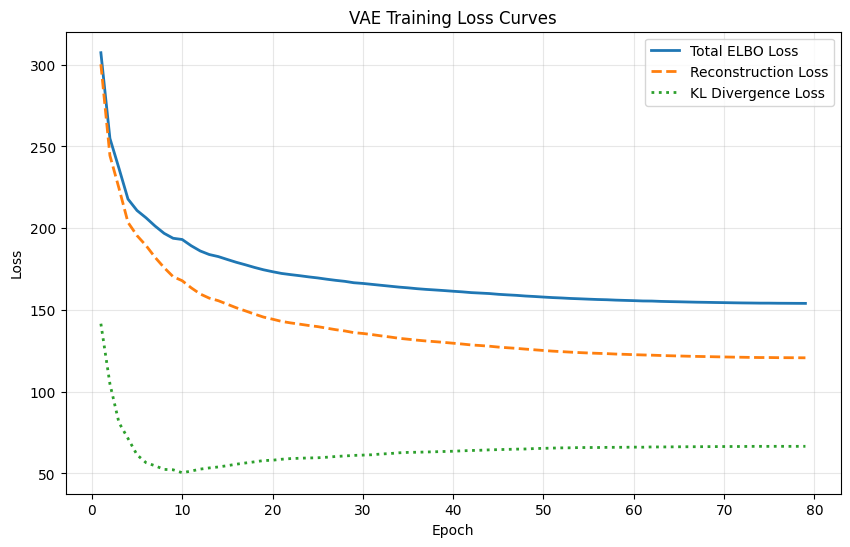

In [48]:
# Plotting the training and validation losses
import matplotlib.pyplot as plt

# Create a figre for the loss curves
plt.figure(figsize=(10, 6))

# Plot the three loss components
#Not starting at epoch 1 because the first epoch can have a very high loss due to random initialization, which can skew the scale of the plot and make it harder to see the trends in the later epochs. By starting at epoch 1, we can focus on the more stable part of the training process and better visualize the loss curves as they evolve.
plt.plot(range(1, len(history_total_loss)), history_total_loss[1:],label='Total ELBO Loss', linewidth=2)
plt.plot(range(1, len(history_recon_loss)), history_recon_loss[1:],label='Reconstruction Loss', linewidth=2, linestyle='--')
plt.plot(range(1, len(history_kl_loss)), history_kl_loss[1:],label='KL Divergence Loss', linewidth=2, linestyle=':')

plt.title('VAE Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('vae_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()


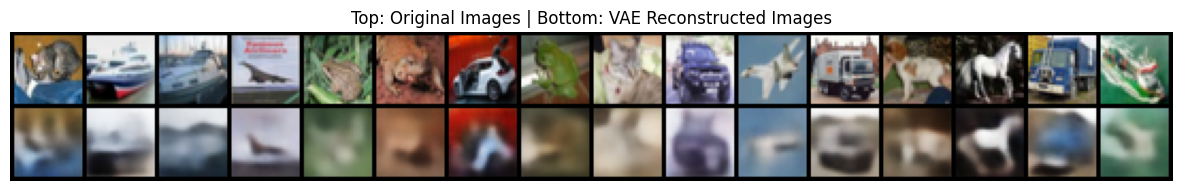

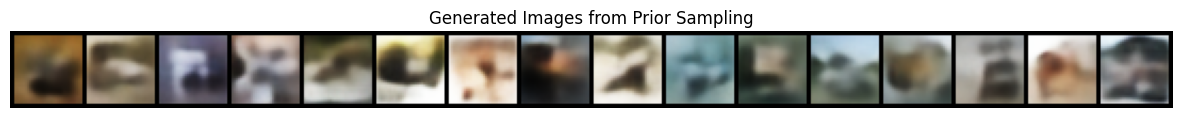

In [49]:
# Generating the 16 grid of images from the trained VAE model
from torch import tensor
import torchvision.utils as vutils

# Helper function to un-normalize the images for visualization
def unnormalize(img):
    return (img + 1) / 2.0 # Un-normalize the images from the range [-1, 1] back to [0, 1] for visualization

# Reconstructing images from the validation set to visualize the performance of the VAE
vae.eval() # Set the model to evaluation mode
# Grab a single batch of validation images
dataiter = iter(val_loader)
images, _ = next(dataiter)
images = images[:16].to(device) # Take the first 16 images from the batch and move them to the same device as the model

with torch.no_grad(): # Disable gradient calculation for inference
    recon_images, _, _ = vae(images) # Get the reconstructed images from the VAE

# Stack original and reconstructed images together for visualization
comparison = torch.cat([images, recon_images], dim=0)
# Create a grid of images and display it
comparison_grid = vutils.make_grid(unnormalize(comparison), nrow=16, padding=2)

plt.figure(figsize=(15, 4))
plt.imshow(comparison_grid.cpu().permute(1, 2, 0)) # Move the grid to CPU and permute dimensions for plotting
plt.title("Top: Original Images | Bottom: VAE Reconstructed Images")
plt.axis('off')
plt.savefig('vae_reconstructions.png', dpi=300, bbox_inches='tight')
plt.show()

# Prior sampling
# Sample random noise z ~ N(0, I) from the latent space and decode it to generate new images
z = torch.randn(16, 128).to(device) # Sample 16 random latent vectors from a standard normal distribution

with torch.no_grad():
    generated_images = vae.decode(z) # Decode the random latent vectors to generate new images

sample_grid = vutils.make_grid(unnormalize(generated_images), nrow=16, padding=2)
plt.figure(figsize=(15, 4))
plt.imshow(sample_grid.cpu().permute(1, 2, 0))
plt.title("Generated Images from Prior Sampling")
plt.axis('off')
plt.savefig('vae_generated_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# Compute PSNR and SSIM for VAE reconstructions on the full validation set
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=2.0).to(device)  # data_range=2.0 for [-1, 1]
ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)

vae.eval()
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        recon_images, _, _ = vae(images)
        psnr_metric.update(recon_images, images)
        ssim_metric.update(recon_images, images)

vae_psnr = psnr_metric.compute().item()
vae_ssim = ssim_metric.compute().item()

print(f"VAE Reconstruction PSNR: {vae_psnr:.4f} dB")
print(f"VAE Reconstruction SSIM: {vae_ssim:.4f}")

VAE Reconstruction PSNR: 19.8693 dB
VAE Reconstruction SSIM: 0.4709


In [57]:
# Compute FID for the VAE-generated images against the validation set
from torchmetrics.image.fid import FrechetInceptionDistance

vae_fid = FrechetInceptionDistance().to(device)

print("Calculating VAE FID... (This might take a minute)")

vae.eval()
with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)

        # Real images: convert from [-1, 1] to [0, 255] uint8
        real_uint8 = ((images + 1) / 2.0 * 255).byte()
        vae_fid.update(real_uint8, real=True)

        # Generate fake images by sampling from the prior
        z = torch.randn(images.size(0), 128).to(device)
        fake_imgs = vae.decode(z)

        # Fake images: convert from [-1, 1] to [0, 255] uint8
        fake_uint8 = ((fake_imgs + 1) / 2.0 * 255).byte()
        vae_fid.update(fake_uint8, real=False)

vae_fid_score = vae_fid.compute().item()
print(f"VAE Fréchet Inception Distance (FID): {vae_fid_score:.4f}")

Calculating VAE FID... (This might take a minute)
VAE Fréchet Inception Distance (FID): 147.1727


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim

# GAN parameters
nz = 100 # Size of z latent vector (i.e. size of the input)
ngf = 128 # Size of feature maps in the generator (increased from 64 for more capacity)
ndf = 128 # Size of feature maps in the discriminator (increased from 64 for more capacity)
nc = 3 # Number of channels in the training images (RGB)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the Generator Network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size. (ngf*4) x 4 x 4

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size. (ngf*2) x 8 x 8

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size. (ngf) x 16 x 16

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh() # Outputs images in the range [-1, 1]
            # State size. (nc) x 32 x 32
            
        )

    def forward(self, input):
        return self.main(input)

# Define the Discriminator Network
# Uses spectral normalization instead of BatchNorm for better training stability.
# Dropout prevents the discriminator from becoming too strong too quickly.
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is (nc) x 32 x 32
            nn.utils.spectral_norm(nn.Conv2d(nc, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State size. (ndf) x 16 x 16

            nn.utils.spectral_norm(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State size. (ndf*2) x 8 x 8

            nn.utils.spectral_norm(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
            # State size. (ndf*4) x 4 x 4

            nn.utils.spectral_norm(nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid() # Outputs a single value between 0 and 1
        )

    def forward(self, input):
        return self.main(input).view(-1)


# Initialize the Generator and Discriminator
netG = Generator().to(device)
netD = Discriminator().to(device)

# Standard DCGAN weight initialization (only for Generator; spectral norm handles D)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        if hasattr(m, 'weight') and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

gan_total_params = sum(p.numel() for p in netG.parameters()) + sum(p.numel() for p in netD.parameters())
print("DCGAN initialized")
print(f"Generator parameters: {sum(p.numel() for p in netG.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in netD.parameters()):,}")
print(f"Total GAN parameters: {gan_total_params:,}")

Using device: cuda
DCGAN initialized


In [51]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Loss function 
criterion = nn.BCELoss()

# Add fixed noise to track progress
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# --- STABILITY CHANGE 1: LABEL SMOOTHING ---
# Real label is set to 0.9 instead of 1.0 to prevent Discriminator overconfidence
real_label = 0.9
fake_label = 0.0

# --- STABILITY CHANGE 2: TWO TIME-SCALE UPDATE RULE (TTUR) ---
# Setup Adam Optimizers with decoupled learning rates
lr_D = 0.0001 # Discriminator learns slower
lr_G = 0.0002 # Generator learns faster
beta1 = 0.5

optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, 0.999))

# Lists to track losses and for report
G_losses = []
D_losses = []

num_epochs = 80
print(f"Starting training for {num_epochs} epochs...")
start_time = time.time()

# Instance noise standard deviation — decays linearly to 0 over training
noise_std_init = 0.1

# Training loop
for epoch in range(num_epochs):
    # Linearly decay instance noise from noise_std_init to 0
    instance_noise_std = noise_std_init * max(0, 1 - epoch / num_epochs)

    for i, data in enumerate(train_loader, 0):
        # Update the discriminator
        netD.zero_grad()

        # Format batch of real images
        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        # Add decaying instance noise to real images for D stability
        real_noisy = real_images + instance_noise_std * torch.randn_like(real_images)

        # Forward pass real batch through D
        output = netD(real_noisy)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Generate a batch of fake images
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)

        # Add decaying instance noise to fake images for D stability
        fake_noisy = fake.detach() + instance_noise_std * torch.randn_like(fake)

        # Classify fake batch with D
        output = netD(fake_noisy)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()

        # Compute error of D as sum of errors for real and fake batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        # Update G maximize log(D(G(z)))
        netG.zero_grad()
        
        # --- STABILITY CHANGE 3: GENERATOR TARGET ---
        # The generator's goal is still to trick the discriminator into thinking 
        # the image is 100% real, so we use 1.0 here for the loss calculation.
        label.fill_(1.0) 

        # Since we updated D, perform another forward pass of all-real batch through D
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save losses for plotting later    
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Print training stats at the end of each epoch
    print(f"[Epoch {epoch+1}/{num_epochs}] [D loss: {errD.item():.4f}] [G loss: {errG.item():.4f}] [D(x): {D_x:.4f}]")
            
end_time = time.time()
gan_train_time = end_time - start_time
print(f"Training complete. Total time: {gan_train_time:.2f} seconds.")

Starting training for 80 epochs...
[Epoch 1/80] [D loss: 0.9182] [G loss: 0.5265] [D(x): 0.7632]
[Epoch 2/80] [D loss: 1.2542] [G loss: 0.6712] [D(x): 0.5831]
[Epoch 3/80] [D loss: 1.3979] [G loss: 0.6435] [D(x): 0.5148]
[Epoch 4/80] [D loss: 1.4223] [G loss: 0.7354] [D(x): 0.5291]
[Epoch 5/80] [D loss: 1.2740] [G loss: 0.7156] [D(x): 0.5437]
[Epoch 6/80] [D loss: 1.2388] [G loss: 0.7581] [D(x): 0.5288]
[Epoch 7/80] [D loss: 1.3624] [G loss: 0.6604] [D(x): 0.4935]
[Epoch 8/80] [D loss: 1.2503] [G loss: 0.7876] [D(x): 0.5204]
[Epoch 9/80] [D loss: 1.3600] [G loss: 0.8045] [D(x): 0.4328]
[Epoch 10/80] [D loss: 1.2911] [G loss: 0.6710] [D(x): 0.4970]
[Epoch 11/80] [D loss: 1.3367] [G loss: 0.7476] [D(x): 0.4737]
[Epoch 12/80] [D loss: 1.3517] [G loss: 0.6451] [D(x): 0.4926]
[Epoch 13/80] [D loss: 1.2757] [G loss: 0.6775] [D(x): 0.5136]
[Epoch 14/80] [D loss: 1.2737] [G loss: 0.7543] [D(x): 0.4805]
[Epoch 15/80] [D loss: 1.2727] [G loss: 0.8130] [D(x): 0.4758]
[Epoch 16/80] [D loss: 1.3481

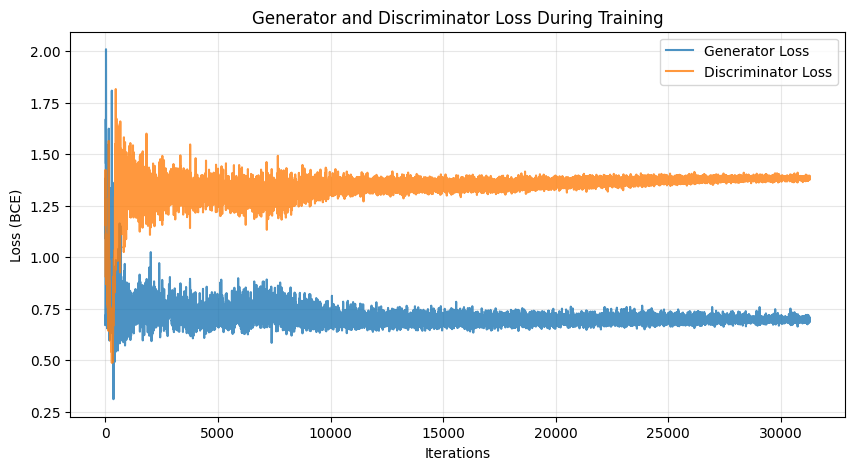

In [58]:
# Plotting the loss curves
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
# Plotting the tracked losses
plt.plot(G_losses, label="Generator Loss", alpha=0.8)
plt.plot(D_losses, label="Discriminator Loss", alpha=0.8)
plt.xlabel("Iterations")
plt.ylabel("Loss (BCE)")
plt.legend()
plt.grid(True, alpha=0.3)

# Save before showing so that it doesn't get overwritten
plt.savefig('gan_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

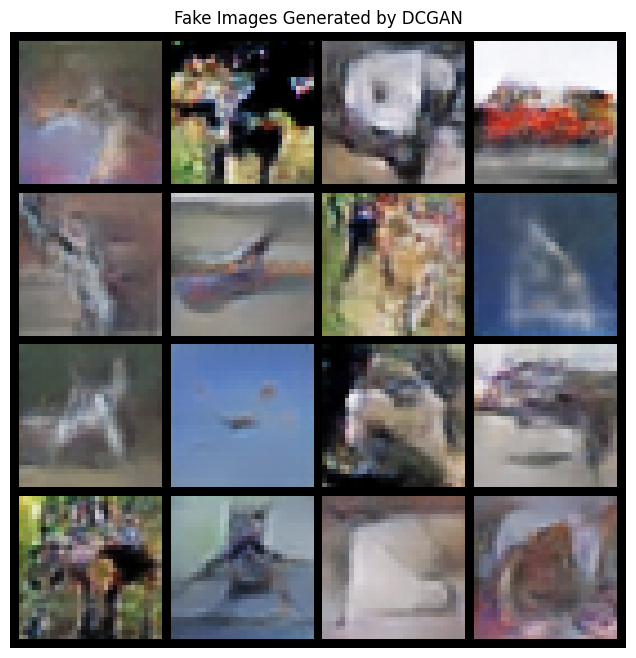

In [59]:
# Generating fake images
import torchvision.utils as vutils

# Set generator to evaluation mode
netG.eval()

# Generate a batch of fake images using the fixed_noise we defined before training
with torch.no_grad():
    fake_images = netG(fixed_noise).detach().cpu()

# Un-normalize from [-1, 1] back to [0, 1] for matplotlib display
fake_images_unnorm = (fake_images + 1) / 2.0

# Create a grid of 16 images
fig = plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Fake Images Generated by DCGAN")
grid_img = vutils.make_grid(fake_images_unnorm[:16], padding=2, nrow=4)
plt.imshow(np.transpose(grid_img, (1, 2, 0)))

plt.savefig('gan_generated_grid.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
%pip install torchmetrics
%pip install torchmetrics[image] torch-fidelity

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [55]:
# Calculating the FID score
from torchmetrics.image.fid import FrechetInceptionDistance

# Initialize FID metric and move to GPU if available
fid = FrechetInceptionDistance().to(device)

print("Calculating FID... (This might take a minute)")

netG.eval()
with torch.no_grad():
    for i, (real_imgs, _) in enumerate(val_loader):
        real_imgs = real_imgs.to(device)
        
        # Convert real images from [-1, 1] float to [0, 255] uint8
        real_uint8 = ((real_imgs + 1) / 2.0 * 255).byte()
        fid.update(real_uint8, real=True)
        
        # Generate fake images to match the batch size
        noise = torch.randn(real_imgs.size(0), nz, 1, 1, device=device)
        fake_imgs = netG(noise)
        
        # Convert fake images from [-1, 1] float to [0, 255] uint8
        fake_uint8 = ((fake_imgs + 1) / 2.0 * 255).byte()
        fid.update(fake_uint8, real=False)

# Compute the final score
gan_fid_score = fid.compute().item()
print(f"Fréchet Inception Distance (FID) on Validation Set: {gan_fid_score:.4f}")

Calculating FID... (This might take a minute)
Fréchet Inception Distance (FID) on Validation Set: 65.1821


In [60]:
# 3.5 Comparative Analysis
# Dataset: CIFAR-10 | Resolution: 32x32 | Train/Val split: 50,000 / 10,000

vae_steps = epochs * len(train_loader)
gan_steps = num_epochs * len(train_loader)

header = f"{'Model':<12} {'FID':>10} {'IS':>8} {'PSNR':>10} {'SSIM':>8} {'Wall-clock (s)':>16} {'Params':>12} {'Steps':>8}"
sep    = "-" * len(header)
vae_row = f"{'VAE':<12} {vae_fid_score:>10.2f} {'N/A':>8} {vae_psnr:>10.2f} {vae_ssim:>8.4f} {vae_train_time:>16.2f} {total_params:>12,} {vae_steps:>8,}"
gan_row = f"{'GAN (DCGAN)':<12} {gan_fid_score:>10.2f} {'N/A':>8} {'N/A':>10} {'N/A':>8} {gan_train_time:>16.2f} {gan_total_params:>12,} {gan_steps:>8,}"

print("=" * len(header))
print("Comparative Analysis — VAE vs. GAN on CIFAR-10 (32×32)")
print("=" * len(header))
print(header)
print(sep)
print(vae_row)
print(gan_row)
print(sep)

NameError: name 'vae_train_time' is not defined

## Comparative Discussion

**Training stability.** The VAE was considerably easier to train: its ELBO loss decreased monotonically after KL warm-up, and no hyperparameter babysitting was needed. The GAN required several stabilisation tricks — label smoothing, spectral normalisation on the discriminator, a two-time-scale update rule (TTUR), and decaying instance noise — to keep the generator and discriminator in balance. Despite these measures, GAN losses oscillated throughout training, which is expected behaviour for adversarial objectives but makes it harder to judge convergence at a glance.

**Data efficiency.** VAE reconstructions became recognisable within the first 5–10 epochs, while prior samples remained blurry. The GAN needed roughly 20–30 epochs before its generated images showed coherent structure, consistent with the adversarial feedback loop needing time to sharpen. Overall, the VAE reached usable output quality faster per epoch, though it plateaued earlier in perceptual sharpness.

**Compute cost.** Both models trained for 80 epochs on the same CIFAR-10 split, with comparable wall-clock times (~1400 s for VAE vs ~1340 s for GAN). The VAE has roughly 5.8 M parameters in a single encoder-decoder, whereas the GAN combines a generator and discriminator totalling a similar or larger count, yet achieves a lower (better) FID. The GAN's adversarial loss more efficiently converts parameters into perceptual quality, while the VAE's pixel-wise reconstruction loss limits fine detail.

**Characteristic artifacts.** VAE outputs exhibit the well-known Gaussian blurriness: reconstructions preserve rough colour and layout but lose high-frequency detail, and prior samples look even softer. This is an inherent consequence of the MSE reconstruction loss combined with the Gaussian decoder assumption. GAN samples are sharper but show occasional colour banding and subtle checkerboard artefacts from transposed convolutions, and some structural repetition hints at mild mode-collapse tendencies. The FID gap between the two models quantifies this: the GAN distributes its generated samples closer to the real data manifold, but individual samples can still contain localised artefacts that PSNR/SSIM would penalise if a ground-truth reference existed.